In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchdiffeq import odeint
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from TrajectoryNet import dataset
import pickle

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Part A: raw 5D PCA space ---
eb_data = dataset.EBData("pcs", max_dim=5)
data_5d = eb_data.data
labels = eb_data.get_times()

scaler_5d = StandardScaler()
data_5d_scaled = scaler_5d.fit_transform(data_5d)

# --- Part B: VAE latent space ---
Z_latent = np.load('../data/Z_latent_active.npy')
labels_vae = np.load('../data/labels.npy')

print(f"Part A — 5D PCA shape: {data_5d_scaled.shape}")
print(f"Part B — VAE latent shape: {Z_latent.shape}")
print(f"Time points: {np.unique(labels)}")

Using device: cuda
Part A — 5D PCA shape: (16819, 5)
Part B — VAE latent shape: (16819, 6)
Time points: [0 1 2 3 4]


In [3]:
def get_data_by_timepoint(data, labels):
    """Returns a dict mapping time point -> tensor of cells at that time point"""
    timepoints = np.unique(labels)
    data_by_t = {}
    for t in timepoints:
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data[mask]).to(device)
    return data_by_t, timepoints

data_by_t_5d, timepoints = get_data_by_timepoint(data_5d_scaled, labels)
data_by_t_vae, _         = get_data_by_timepoint(Z_latent, labels_vae)

print("Cells per time point:")
for t in timepoints:
    print(f"  t={t}: {data_by_t_5d[t].shape[0]} cells")

Cells per time point:
  t=0: 2381 cells
  t=1: 4163 cells
  t=2: 3278 cells
  t=3: 3665 cells
  t=4: 3332 cells


In [4]:
def mmd_loss(x, y, kernel_scales=[0.1, 0.5, 1.0, 2.0, 5.0]):
    """
    Maximum Mean Discrepancy between two sets of points x and y.
    Uses RBF kernel averaged over multiple length scales.
    This is the standard distributional loss for single-cell trajectory models
    since we never observe the same cell at multiple time points.
    """
    def rbf_kernel(a, b, scale):
        dist = torch.cdist(a, b).pow(2)
        return torch.exp(-dist / (2 * scale ** 2))
    
    loss = 0.0
    for scale in kernel_scales:
        Kxx = rbf_kernel(x, x, scale).mean()
        Kyy = rbf_kernel(y, y, scale).mean()
        Kxy = rbf_kernel(x, y, scale).mean()
        loss += Kxx + Kyy - 2 * Kxy
    return loss / len(kernel_scales)

In [5]:
class ODEFunc(nn.Module):
    """
    Learns the vector field f(z, t) = dz/dt
    Architecture follows TrajectoryNet: 3 FC layers, 64 nodes, leaky ReLU
    Input: cell state concatenated with time
    Output: derivative of cell state w.r.t. time
    """
    def __init__(self, dim, hidden_dim=64):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),  # +1 for time
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, dim)
        )
    
    def forward(self, t, z):
        # append time as an extra feature
        t_vec = t.expand(z.shape[0], 1)
        inp = torch.cat([z, t_vec], dim=1)
        return self.net(inp)

In [12]:
def train_neural_ode(data_by_t, timepoints, dim,
                     epochs=300, lr=1e-3, n_samples=500,
                     energy_weight=0.1):
    
    model = ODEFunc(dim=dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
    
    t_span = torch.FloatTensor(timepoints).to(device)
    losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        idx = torch.randperm(data_by_t[0].shape[0])[:n_samples]
        z0 = data_by_t[0][idx]
        
        z_pred = odeint(model, z0, t_span, method='dopri5')
        
        mmd = 0.0
        energy = 0.0
        
        for i, t in enumerate(timepoints):
            z_pred_t = z_pred[i]
            idx_obs = torch.randperm(data_by_t[t].shape[0])[:n_samples]
            z_obs_t = data_by_t[t][idx_obs]
            mmd += mmd_loss(z_pred_t, z_obs_t)
            
            # energy regularization: penalize large velocities
            t_tensor = torch.tensor(float(t)).to(device)
            vel = model(t_tensor, z_pred_t)
            energy += vel.pow(2).mean()
        
        loss = mmd + energy_weight * energy
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"MMD: {mmd.item():.4f} | "
                  f"Energy: {energy.item():.4f} | "
                  f"Total: {loss.item():.4f}")
    
    return model, losses

In [13]:
#training neural ode on 5d pCA
print("=" * 50)
print("Part A: Neural ODE on 5D PCA space")
print("=" * 50)

model_5d, losses_5d = train_neural_ode(
    data_by_t=data_by_t_5d,
    timepoints=timepoints,
    dim=5,
    epochs=300,
    lr=1e-3,
    n_samples=500
)

torch.save(model_5d.state_dict(), '../models/node_5d.pt')
print("Saved node_5d.pt")

Part A: Neural ODE on 5D PCA space
Epoch 30/300 | MMD: 0.1773 | Energy: 0.8438 | Total: 0.2617
Epoch 60/300 | MMD: 0.1093 | Energy: 0.9879 | Total: 0.2081
Epoch 90/300 | MMD: 0.0883 | Energy: 0.8985 | Total: 0.1781
Epoch 120/300 | MMD: 0.0909 | Energy: 0.9042 | Total: 0.1813
Epoch 150/300 | MMD: 0.0846 | Energy: 0.8965 | Total: 0.1743
Epoch 180/300 | MMD: 0.0808 | Energy: 0.8814 | Total: 0.1689
Epoch 210/300 | MMD: 0.0754 | Energy: 0.8815 | Total: 0.1636
Epoch 240/300 | MMD: 0.0700 | Energy: 0.8741 | Total: 0.1574
Epoch 270/300 | MMD: 0.0826 | Energy: 0.8914 | Total: 0.1717
Epoch 300/300 | MMD: 0.0694 | Energy: 0.8478 | Total: 0.1542
Saved node_5d.pt


In [14]:
print("=" * 50)
print("Part B: Neural ODE on VAE latent space (6D active)")
print("=" * 50)

model_vae, losses_vae = train_neural_ode(
    data_by_t=data_by_t_vae,
    timepoints=timepoints,
    dim=6,
    epochs=300,
    lr=1e-3,
    n_samples=500
)

torch.save(model_vae.state_dict(), '../models/node_vae.pt')
print("Saved node_vae.pt")

Part B: Neural ODE on VAE latent space (6D active)
Epoch 30/300 | MMD: 0.1043 | Energy: 0.0010 | Total: 0.1044
Epoch 60/300 | MMD: 0.0691 | Energy: 0.0007 | Total: 0.0691
Epoch 90/300 | MMD: 0.0657 | Energy: 0.0009 | Total: 0.0657
Epoch 120/300 | MMD: 0.0529 | Energy: 0.0008 | Total: 0.0530
Epoch 150/300 | MMD: 0.0650 | Energy: 0.0008 | Total: 0.0651
Epoch 180/300 | MMD: 0.0514 | Energy: 0.0009 | Total: 0.0514
Epoch 210/300 | MMD: 0.0507 | Energy: 0.0010 | Total: 0.0508
Epoch 240/300 | MMD: 0.0499 | Energy: 0.0010 | Total: 0.0500
Epoch 270/300 | MMD: 0.0532 | Energy: 0.0011 | Total: 0.0534
Epoch 300/300 | MMD: 0.0526 | Energy: 0.0011 | Total: 0.0527
Saved node_vae.pt


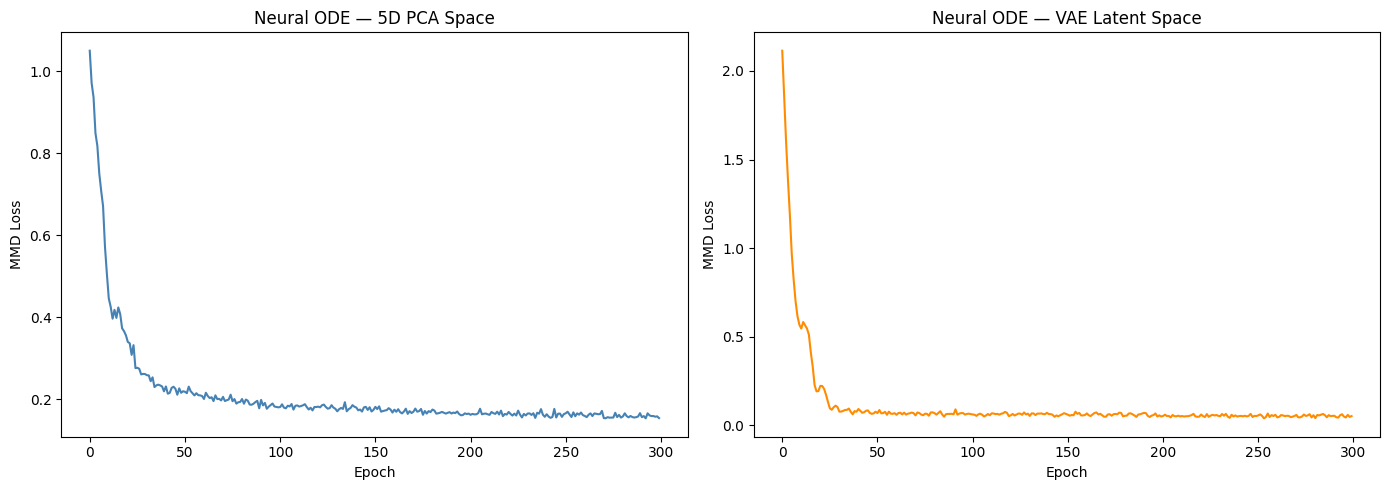

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_5d, color='steelblue')
axes[0].set_title('Neural ODE — 5D PCA Space')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MMD Loss')

axes[1].plot(losses_vae, color='darkorange')
axes[1].set_title('Neural ODE — VAE Latent Space')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MMD Loss')

plt.tight_layout()
plt.savefig('../figures/03_node_training_curves.png', dpi=150)
plt.show()

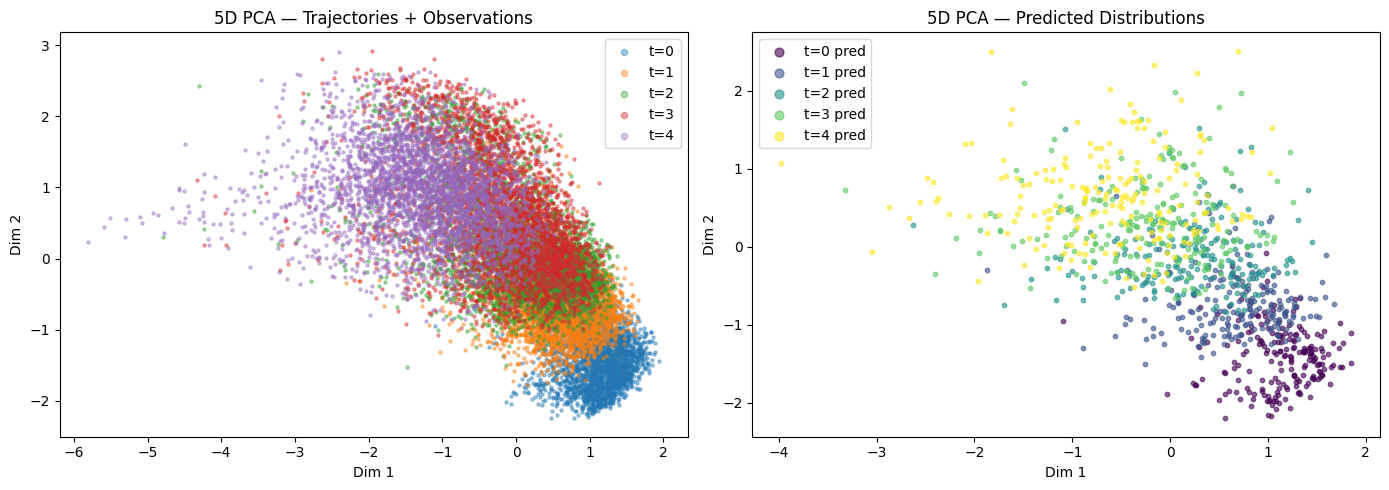

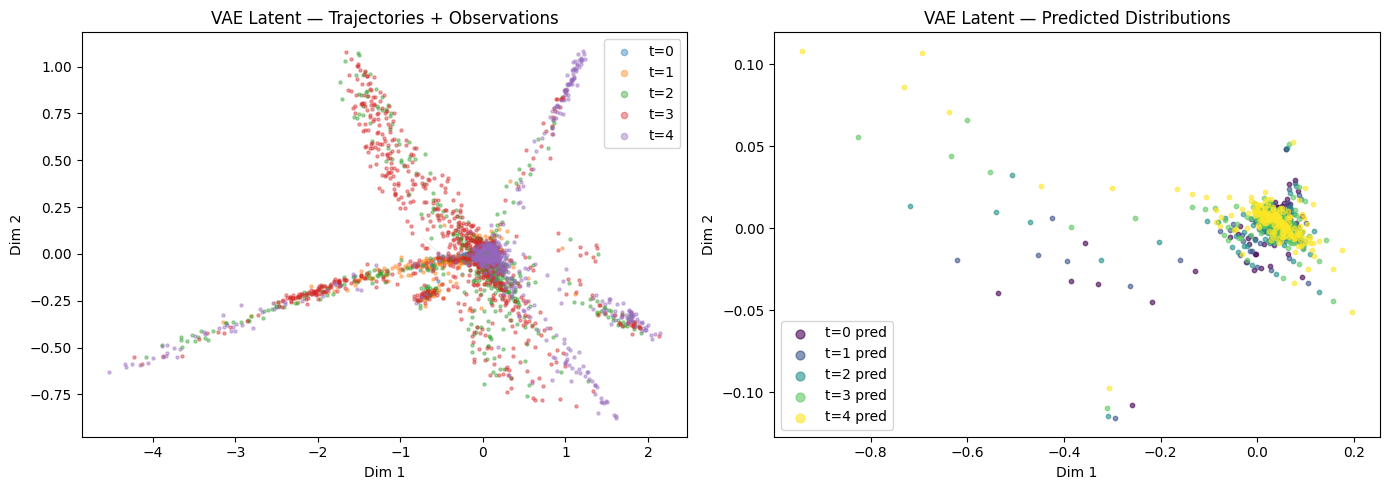

In [16]:
def plot_trajectories(model, data_by_t, timepoints, dim, title, filename, n_traj=200):
    model.eval()
    t_span = torch.FloatTensor(timepoints).to(device)
    
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_traj]
        z0 = data_by_t[0][idx]
        z_pred = odeint(model, z0, t_span, method='dopri5')
        z_pred = z_pred.cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # plot predicted trajectories
    for i in range(min(50, n_traj)):
        axes[0].plot(z_pred[:, i, 0], z_pred[:, i, 1], 
                    alpha=0.2, color='gray', linewidth=0.5)
    
    # overlay observed cells colored by time
    for t in timepoints:
        obs = data_by_t[t].cpu().numpy()
        axes[0].scatter(obs[:, 0], obs[:, 1], 
                       s=5, alpha=0.4, label=f't={t}')
    
    axes[0].set_title(f'{title} — Trajectories + Observations')
    axes[0].set_xlabel('Dim 1')
    axes[0].set_ylabel('Dim 2')
    axes[0].legend(markerscale=2)
    
    # plot predicted distributions at each time point
    colors = plt.cm.viridis(np.linspace(0, 1, len(timepoints)))
    for i, t in enumerate(timepoints):
        axes[1].scatter(z_pred[i, :, 0], z_pred[i, :, 1],
                       s=10, alpha=0.6, color=colors[i], label=f't={t} pred')
    
    axes[1].set_title(f'{title} — Predicted Distributions')
    axes[1].set_xlabel('Dim 1')
    axes[1].set_ylabel('Dim 2')
    axes[1].legend(markerscale=2)
    
    plt.tight_layout()
    plt.savefig(f'../figures/{filename}', dpi=150)
    plt.show()

plot_trajectories(model_5d, data_by_t_5d, timepoints, 
                  dim=5, title='5D PCA', 
                  filename='03_trajectories_5d.png')

plot_trajectories(model_vae, data_by_t_vae, timepoints,
                  dim=6, title='VAE Latent',
                  filename='03_trajectories_vae.png')

In [17]:
from scipy.stats import wasserstein_distance

def evaluate_held_out(model, data_by_t, timepoints, dim, n_samples=500):
    """
    Standard evaluation protocol from TrajectoryNet:
    Leave one time point out, predict it, measure Wasserstein distance
    """
    model.eval()
    results = {}
    
    with torch.no_grad():
        for held_out_t in timepoints[1:-1]:  # skip first and last
            t_span = torch.FloatTensor(timepoints).to(device)
            
            idx = torch.randperm(data_by_t[0].shape[0])[:n_samples]
            z0 = data_by_t[0][idx]
            
            z_pred = odeint(model, z0, t_span, method='dopri5')
            
            # get predicted distribution at held out time point
            t_idx = list(timepoints).index(held_out_t)
            z_pred_t = z_pred[t_idx].cpu().numpy()
            z_obs_t = data_by_t[held_out_t].cpu().numpy()
            
            # compute wasserstein distance per dimension then average
            w_dist = np.mean([
                wasserstein_distance(z_pred_t[:, d], z_obs_t[:, d])
                for d in range(dim)
            ])
            results[held_out_t] = w_dist
            print(f"  Held out t={held_out_t}: Wasserstein = {w_dist:.4f}")
    
    avg = np.mean(list(results.values()))
    print(f"  Average Wasserstein: {avg:.4f}")
    return results, avg

print("Part A — 5D PCA:")
results_5d, avg_5d = evaluate_held_out(model_5d, data_by_t_5d, timepoints, dim=5)

print("\nPart B — VAE Latent:")
results_vae, avg_vae = evaluate_held_out(model_vae, data_by_t_vae, timepoints, dim=6)

print(f"\nSummary:")
print(f"  5D PCA avg Wasserstein:     {avg_5d:.4f}")
print(f"  VAE Latent avg Wasserstein: {avg_vae:.4f}")

Part A — 5D PCA:
  Held out t=1: Wasserstein = 0.1905
  Held out t=2: Wasserstein = 0.1824
  Held out t=3: Wasserstein = 0.2075
  Average Wasserstein: 0.1935

Part B — VAE Latent:
  Held out t=1: Wasserstein = 0.0194
  Held out t=2: Wasserstein = 0.1021
  Held out t=3: Wasserstein = 0.1439
  Average Wasserstein: 0.0884

Summary:
  5D PCA avg Wasserstein:     0.1935
  VAE Latent avg Wasserstein: 0.0884
